<a href="https://colab.research.google.com/github/Hardik-India/Machine_Learning/blob/main/Batch_Gradient_Descent_own_Class_2D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

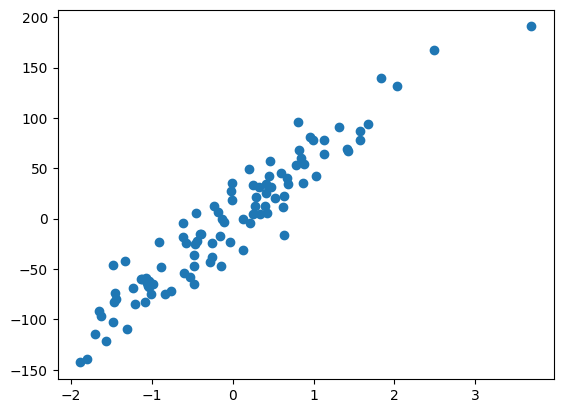

In [2]:
x,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20)
plt.scatter(x,y)

In [3]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x,y)

LinearRegression()

In [4]:
lr.coef_

array([60.66437136])

In [5]:
lr.intercept_

np.float64(-0.7364987960924099)

In [6]:
np.mean(cross_val_score(lr,x,y,scoring='r2',cv=10))

np.float64(0.8767721197621077)

In [7]:
class GDRegressor:

  def __init__(self, learning_rate, epochs):
    self.m = 100
    self.b = -120
    self.lr = learning_rate
    self.epochs = epochs

  def fit(self, x, y):
    # calculate the b and m using GD
    for i in range(self.epochs):
      loss_slope_b = -2 * np.sum(y - self.m * x.ravel() - self.b)
      loss_slope_m = -2 * np.sum((y - self.m * x.ravel() - self.b)*x.ravel())
      self.b = self.b - (self.lr * loss_slope_b)
      self.m = self.m - (self.lr * loss_slope_m)
      plt.plot(x,self.m*x+self.b)
    plt.scatter(x,y)
    print(self.m,self.b)

  def predict(self, x):
    return self.m * x + self.b

In [8]:
gd = GDRegressor(0.006,20)

60.66437137781393 -0.7364988078494129


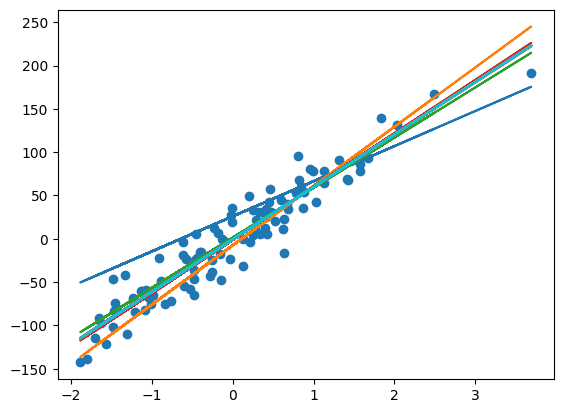

In [9]:
gd.fit(x,y)

In [10]:
gd.predict(x[0])

array([-100.95037565])

In [11]:
lr.predict(x[0].reshape(-1,1))

array([-100.95037561])